In [1]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

print('All imports successful!')


All imports successful!


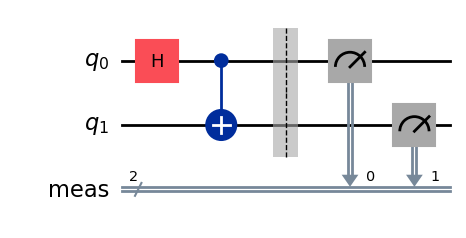

In [3]:
# Create a quantum circuit with 2 qubits and 2 classical bits
qc = QuantumCircuit(2)

# Step 1: Put qubit 0 into superposition
# The Hadamard gate transforms |0> into (|0> + |1>)/sqrt(2)
qc.h(0)

# Step 2: Entangle qubit 0 and qubit 1
# CNOT: if qubit 0 is |1>, flip qubit 1
qc.cx(0, 1)
# Step 3: Measure both qubits
qc.measure_all()

# Draw the circuit
qc.draw('mpl')


Simulator Results:
{'00': 522, '11': 502}



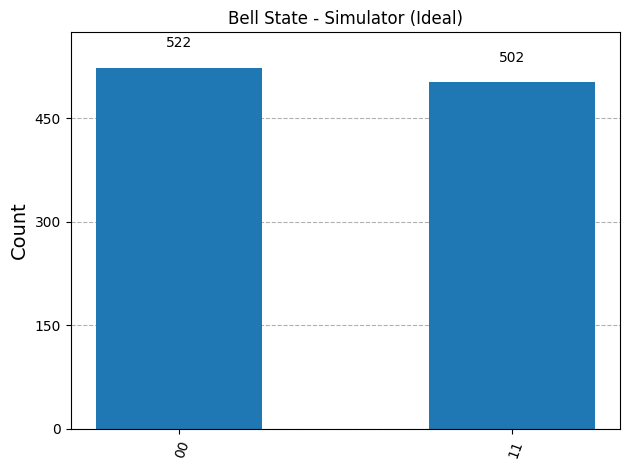

In [4]:
# Run on the local Aer simulator (no internet needed)
simulator = AerSimulator()
result = simulator.run(qc, shots=1024).result()
counts = result.get_counts()

print('Simulator Results:')
print(counts)
print()

# Plot the results as a histogram
plot_histogram(counts, title='Bell State - Simulator (Ideal)')


In [5]:
# Connect to IBM Quantum
service = QiskitRuntimeService()

# Select the least-busy backend with enough qubits
backend = service.least_busy(
    min_num_qubits=2,
    operational=True,
    simulator=False
)
print(f'Running on: {backend.name} ({backend.num_qubits} qubits)')

# Transpile the circuit for the real hardware
# (real chips have constraints on which qubits can interact)
pm = generate_preset_pass_manager(
    optimization_level=1,
    backend=backend
)
transpiled = pm.run(qc)

# Run on real hardware using the Sampler
sampler = SamplerV2(mode=backend)
job = sampler.run([transpiled], shots=1024)
print(f'Job ID: {job.job_id()}')
print('Job submitted! Waiting for results...')
print('(This may take a few minutes as your job waits in the queue)')

result = job.result()
counts_real = result[0].data.meas.get_counts()

print()
print('Real Hardware Results:')
print(counts_real)


Running on: ibm_torino (133 qubits)
Job ID: d6bt19cnsg9c7399e8o0
Job submitted! Waiting for results...
(This may take a few minutes as your job waits in the queue)

Real Hardware Results:
{'10': 99, '01': 60, '11': 401, '00': 464}


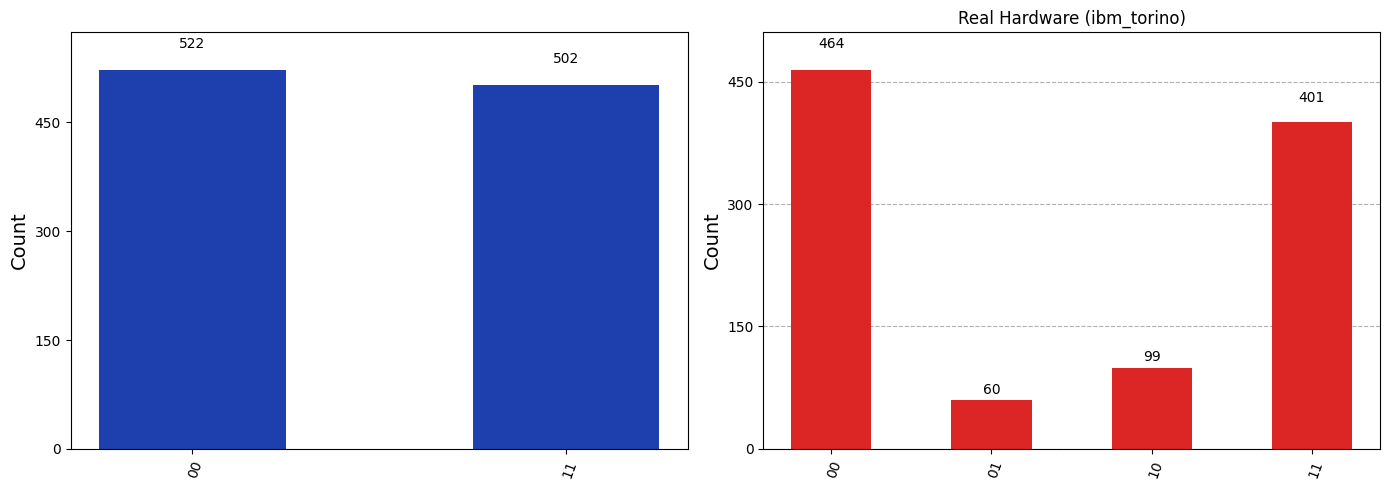

Figure saved as bell_state_comparison.png

--- CONVERGENCE INSIGHT ---
The gap between these two histograms is quantum noise.
Convergence's AI layer will learn to close this gap.


In [6]:
# Side-by-side comparison
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
plot_histogram(counts, ax=ax1,
    title='Simulator (Ideal)',
    color='#1E40AF')

plot_histogram(counts_real, ax=ax2,
    title=f'Real Hardware ({backend.name})',
    color='#DC2626')

plt.tight_layout()
plt.savefig('bell_state_comparison.png', dpi=150,
    bbox_inches='tight')
plt.show()

print('Figure saved as bell_state_comparison.png')
print()
print('--- CONVERGENCE INSIGHT ---')
print('The gap between these two histograms is quantum noise.')
print('Convergence\'s AI layer will learn to close this gap.')
